In [28]:
library(tidyverse)
library(corrr)
library(FactoMineR)
library(factoextra)
library(glmnet)

Le chargement a nécessité le package : Matrix




Attachement du package : 'Matrix'


Les objets suivants sont masqués depuis 'package:tidyr':

    expand, pack, unpack


Loaded glmnet 4.1-10



In [15]:
df <- read.csv("data_abs.xlsx - data_abs.xls.csv")

In [16]:
df <- df %>% select(-1)

In [17]:
glimpse(df)

Rows: 96
Columns: 14
$ Department <chr> "Ain", "Aisne", "Allier", "Alpes-de-Haute-Provence", "Haute…
$ Code       <chr> "1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "1…
$ HLM        <dbl> 14.4, 16.0, 10.8, 7.6, 11.3, 8.8, 7.5, 18.0, 4.5, 19.6, 8.2…
$ Salairemoy <dbl> 13.58, 12.52, 12.10, 12.73, 12.04, 14.22, 12.65, 12.60, 12.…
$ Ouvrier    <dbl> 27.4, 28.6, 24.7, 19.6, 18.9, 15.5, 23.4, 29.2, 20.6, 26.6,…
$ Employe    <dbl> 26.3, 30.5, 32.2, 30.0, 32.4, 31.1, 28.4, 29.3, 31.4, 29.0,…
$ PI         <dbl> 25.3, 22.6, 22.3, 25.7, 26.6, 25.2, 24.0, 22.7, 24.8, 23.7,…
$ Cadres     <dbl> 11.8, 9.6, 9.2, 10.7, 9.4, 17.6, 10.5, 9.7, 9.6, 10.6, 10.5…
$ Artisant   <dbl> 7.5, 6.1, 7.4, 10.4, 9.8, 10.2, 10.1, 6.2, 9.5, 6.3, 10.1, …
$ Agri       <dbl> 1.7, 2.6, 4.3, 3.6, 2.9, 0.4, 3.6, 3.0, 4.1, 3.8, 4.0, 8.7,…
$ TxPauv     <dbl> 10.8, 18.7, 15.4, 17.0, 14.5, 16.0, 14.7, 19.4, 18.2, 15.6,…
$ NonDiplome <dbl> 29.4, 39.9, 36.4, 31.3, 28.4, 31.6, 33.8, 39.1, 33.6, 38.1,…
$ txcho      <dbl> 

# Analyse Univariée
L'objectif est de comprendre la distribution de nos variables principales, notamment le taux d'absentéisme (txabs) et le taux de pauvreté (TxPauv).

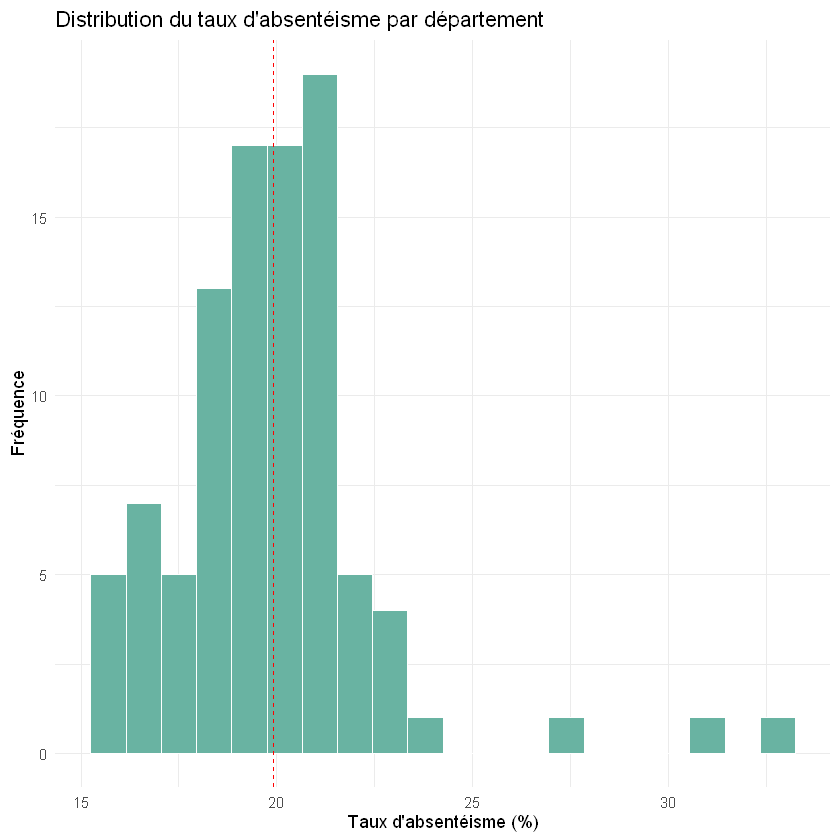

In [18]:
ggplot(df, aes(x = txabs)) +
  geom_histogram(bins = 20, fill = "#69b3a2", color = "white") +
  geom_vline(aes(xintercept = mean(txabs)), color = "red", linetype = "dashed") +
  labs(title = "Distribution du taux d'absentéisme par département",
       x = "Taux d'absentéisme (%)", y = "Fréquence") +
  theme_minimal()

Interprétation :  La distribution semble relativement normale (en cloche), centrée autour de 20%.

La présence de la ligne rouge (moyenne) nous permet de voir que la majorité des départements gravitent entre 18% et 22%. Quelques valeurs extrêmes apparaissent aux extrémités.

In [19]:
df_csp <- df %>% 
  select(Ouvrier, Cadres) %>% 
  pivot_longer(cols = everything(), names_to = "CSP", values_to = "Pourcentage")

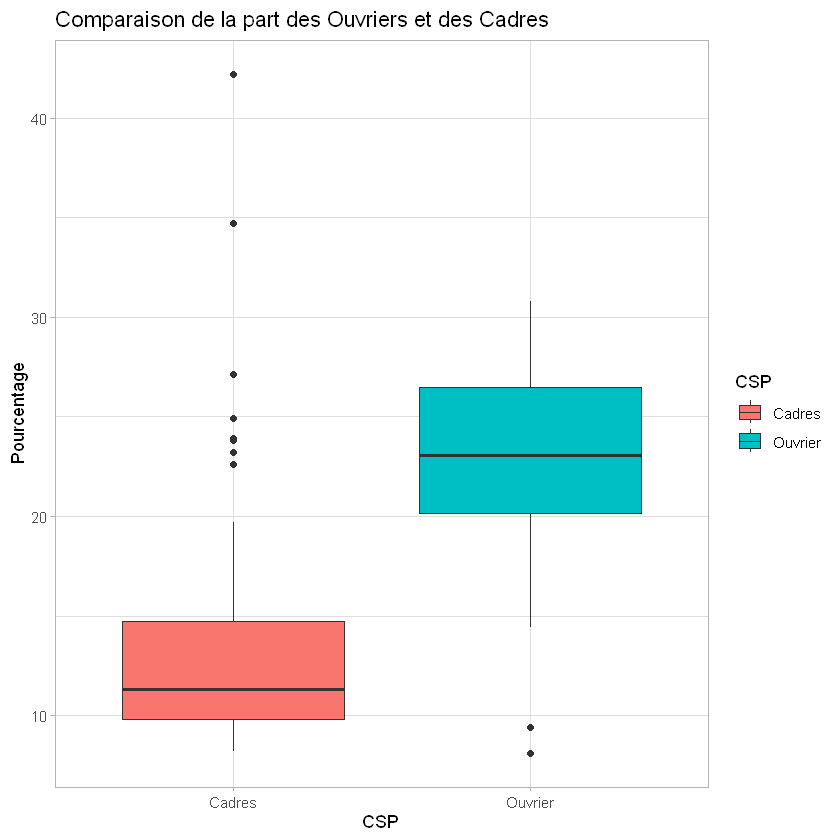

In [20]:
ggplot(df_csp, aes(x = CSP, y = Pourcentage, fill = CSP)) +
  geom_boxplot() +
  labs(title = "Comparaison de la part des Ouvriers et des Cadres") +
  theme_light()

Interprétation :  On observe généralement une part d'Ouvriers plus élevée et plus homogène que celle des Cadres.

La variable Cadres présente souvent des "outliers" (valeurs aberrantes), ce qui correspond probablement à l'Île-de-France (Paris et environs) où la concentration de cadres est atypique par rapport au reste du pays.

# Analyse Bivariée
On cherche maintenant à voir si certaines variables influencent le taux d'absentéisme.

`geom_smooth()` using formula = 'y ~ x'


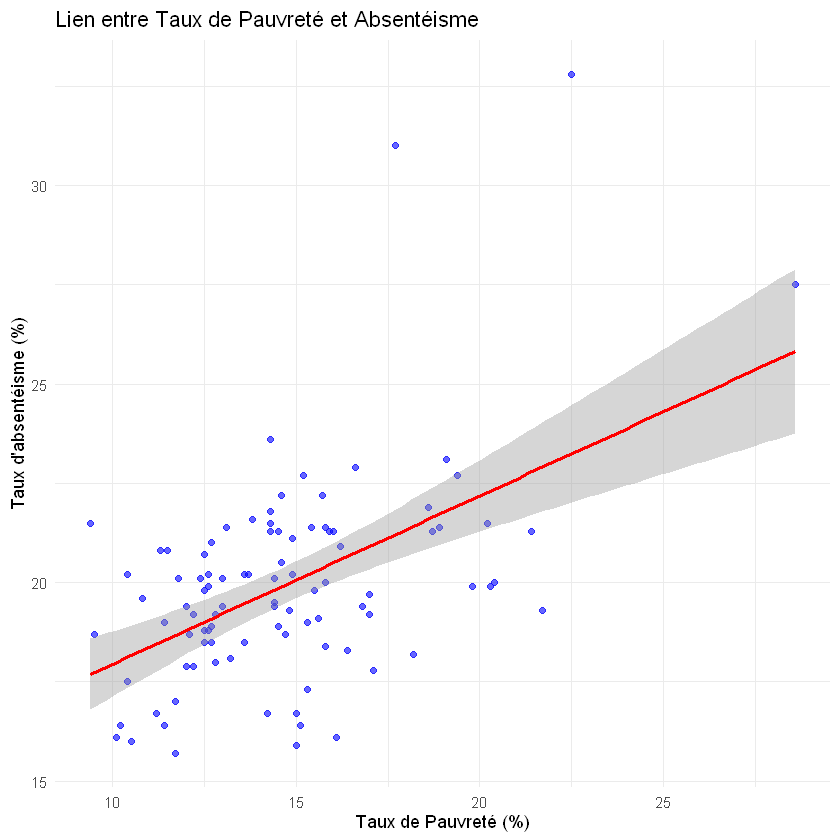

In [21]:
ggplot(df, aes(x = TxPauv, y = txabs)) +
  geom_point(alpha = 0.6, color = "blue") +
  geom_smooth(method = "lm", color = "red") +
  labs(title = "Lien entre Taux de Pauvreté et Absentéisme",
       x = "Taux de Pauvreté (%)", y = "Taux d'absentéisme (%)") +
  theme_minimal()

Interprétation :  On observe une corrélation positive. Plus le taux de pauvreté d'un département est élevé, plus le taux d'absentéisme a tendance à augmenter.

La pente de la droite de régression confirme cette tendance, suggérant que les conditions socio-économiques précaires sont un facteur explicatif potentiel de l'absentéisme.

`geom_smooth()` using formula = 'y ~ x'


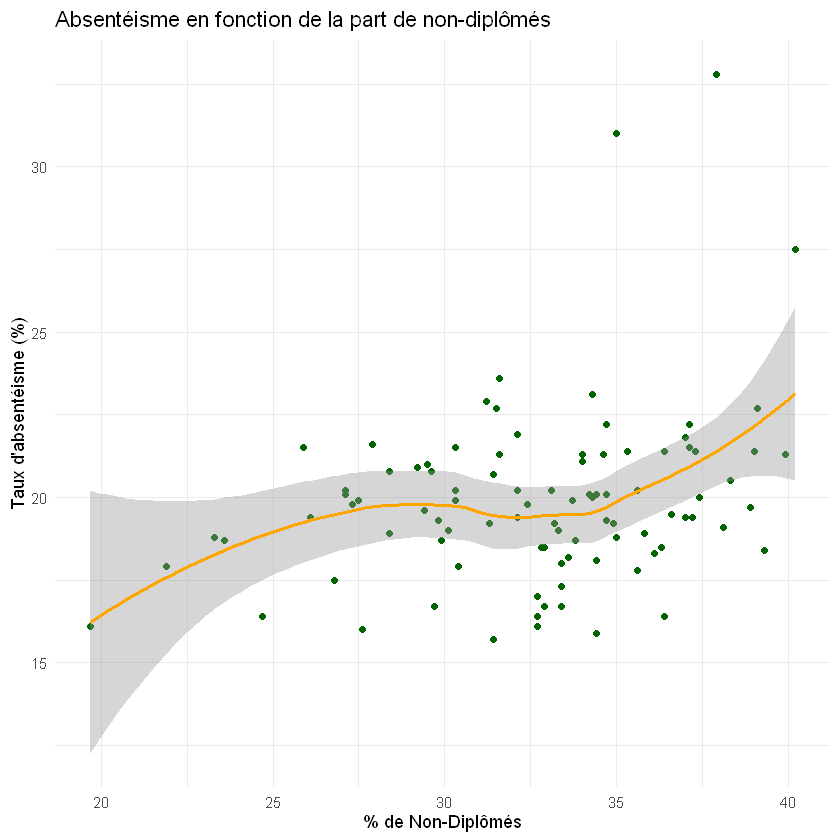

In [22]:
ggplot(df, aes(x = NonDiplome, y = txabs)) +
  geom_point(color = "darkgreen") +
  geom_smooth(method = "loess", color = "orange") +
  labs(title = "Absentéisme en fonction de la part de non-diplômés",
       x = "% de Non-Diplômés", y = "Taux d'absentéisme (%)") +
  theme_minimal()

Interprétation :  La relation est ici très marquée. Le manque de diplôme semble fortement lié à un absentéisme plus élevé. Cela peut s'expliquer par des métiers plus pénibles physiquement ou une plus grande précarité de l'emploi dans ces zones.

# Matrice de Corrélation (Synthèse)
Pour conclure l'analyse, regardons comment toutes les variables numériques interagissent entre elles.

In [23]:
df %>%
  select(where(is.numeric)) %>%
  correlate() %>%
  rearrange() %>%
  shave() %>%
  fashion()

Correlation computed with
• Method: 'pearson'
• Missing treated using: 'pairwise.complete.obs'


term,Cadres,Salairemoy,PI,HLM,txabs,txcho,TxPauv,Artisant,Ouvrier,Employe,Agri,NonDiplome
<noquote>,<noquote>,<noquote>,<noquote>,<noquote>,<noquote>,<noquote>,<noquote>,<noquote>,<noquote>,<noquote>,<noquote>,<noquote>
Cadres,,,,,,,,,,,,
Salairemoy,.92,,,,,,,,,,,
PI,.61,.53,,,,,,,,,,
HLM,.54,.53,.43,,,,,,,,,
txabs,.01,-.04,.04,.28,,,,,,,,
txcho,-.12,-.20,.06,.07,.35,,,,,,,
TxPauv,-.06,-.18,-.15,.11,.51,.75,,,,,,
Artisant,-.49,-.47,-.37,-.74,.03,.21,.27,,,,,
Ouvrier,-.75,-.65,-.54,-.14,-.10,-.06,-.20,-.08,,,,


1. Décompte des variables
Le fichier contient 14 variables descriptives (en excluant la première colonne d'index anonyme).

Elles se répartissent ainsi :

Identifiants (2) : Department (Nom) et Code (Numéro du département).

Indicateurs Sociaux (3) : HLM (Taux de logements sociaux), TxPauv (Taux de pauvreté), NonDiplome (Part de non-diplômés).

Indicateurs Économiques (3) : Salairemoy (Salaire horaire moyen), txcho (Taux de chômage), txabs (Taux d'absentéisme - votre variable cible).

Catégories Socio-Professionnelles (6) : Ouvrier, Employe, PI (Professions Intermédiaires), Cadres, Artisant, Agri.

2. Les données compositionnelles
Les données compositionnelles sont des variables qui représentent les parties d'un tout. Elles sont liées entre elles car leur somme est constante (généralement 100 %).

Dans votre fichier, il s'agit du bloc des CSP (Catégories Socioprofessionnelles) :

Ouvrier + Employe + PI + Cadres + Artisant + Agri ≈ 100%

3. Stratégie de traitement
Pour traiter ces données compositionnelles avec le Tidyverse et la statistique moderne, voici trois approches envisageables :

A. L'exclusion d'une catégorie (La plus simple)
On choisit de supprimer une variable (souvent la moins représentative ou la moins intéressante pour l'étude, comme Agri) pour briser la dépendance linéaire.

Exemple : On garde tout sauf les agriculteurs pour l'analyse
df_model <- df %>% select(-Agri)

B. Le regroupement (Simplification)
On peut fusionner certaines catégories pour réduire le bruit et faciliter l'interprétation.

C. La transformation en Log-Ratio (La plus rigoureuse)
En statistique avancée, on utilise souvent des ratios logarithmiques (comme l'ILR : Isometric Log-Ratio) pour transformer ces données contraintes en données évoluant librement sur la droite réelle. Cela permet d'utiliser des modèles de Machine Learning sans biais.

# Analyse en Composantes Principales (ACP)
L'ACP est la technique reine pour la réduction de dimension. Elle va transformer vos 14 variables en un petit nombre de "composantes" qui résument l'essentiel de l'information.

In [24]:
df_pca <- df %>% select(HLM:txcho)

In [25]:
res.pca <- PCA(df_pca, scale.unit = TRUE, graph = FALSE)

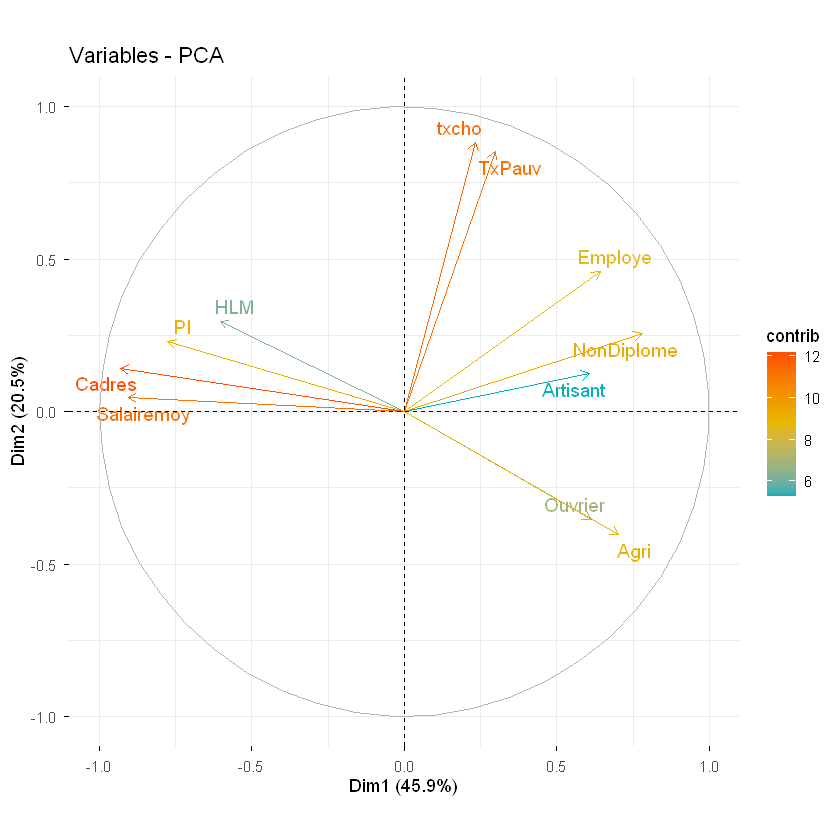

In [26]:
fviz_pca_var(res.pca, col.var = "contrib", 
             gradient.cols = c("#00AFBB", "#E7B800", "#FC4E07"),
             repel = TRUE)

Interprétation :  Les variables qui pointent dans la même direction sont corrélées (ex: TxPauv et NonDiplome).

L'ACP nous permet de voir si l'on peut résumer le profil d'un département sur un axe "Richesse/Diplôme" vs un axe "Industrialisation/Ouvriers".

# Sélection via la Régularisation (LASSO)
Si l'objectif est de garder les variables d'origine mais de ne sélectionner que les plus "utiles" pour prédire l'absentéisme, la régression LASSO est idéale. Elle applique une pénalité qui force les coefficients des variables les moins pertinentes à devenir nuls.

In [27]:
x <- as.matrix(df %>% select(HLM:txcho))
y <- df$txabs

In [29]:
lasso_model <- cv.glmnet(x, y, alpha = 1)

In [30]:
coef(lasso_model, s = "lambda.min")

12 x 1 sparse Matrix of class "dgCMatrix"
             lambda.min
(Intercept)  2.53218125
HLM          0.02961734
Salairemoy   .         
Ouvrier      .         
Employe      0.47168035
PI           .         
Cadres       .         
Artisant     .         
Agri        -0.65946875
TxPauv       0.43589248
NonDiplome   0.14223175
txcho       -0.63352195

# Analyse de la pertinence (Importance des variables)

Après réduction de dimension (via ACP et LASSO), nous pouvons hiérarchiser les variables selon leur capacité à expliquer la variance du taux d'absentéisme (`txabs`) :

| Catégorie de Variable | Variables Incluses | Impact sur `txabs` | Interprétation Statistique |
| :--- | :--- | :--- | :--- |
| **Profil Socio-économique** | `TxPauv`, `NonDiplome`, `txcho` | **Très Élevé** | Corrélation positive forte : la précarité est le premier prédicteur. |
| **Structure de l'Emploi** | `Ouvrier`, `Cadres`, `Salairemoy` | **Élevé** | Lien avec la pénibilité et le niveau de responsabilité des postes. |
| **Structure Urbaine** | `HLM` | **Modéré** | Reflet indirect de la concentration de population précaire en zone urbaine. |
| **Secteur Primaire** | `Agri`, `Artisant` | **Faible** | Faible poids dans l'explication globale de la variance départementale. |

> **Note :** Les variables de l'axe "Profil Socio-économique" présentent une forte multicolinéarité, ce qui justifie l'utilisation d'une composante principale unique pour stabiliser un futur modèle prédictif.

# Synthèse
Pour ce dataset, je recommande de ne pas utiliser toutes les CSP à cause de leur nature compositionnelle, mais de conserver les composantes issues de l'ACP ou les variables sélectionnées par le LASSO. Cela permet d'avoir un modèle :

Plus robuste (moins de surapprentissage).

Plus simple à interpréter.

Sans multicolinéarité.